In [3]:
# Import Libraries and Load Dataset
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
df = pd.read_csv('student_performance_data.csv')

In [3]:
df.head(5)

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


## Data Cleaning

In [4]:
# Check Dataset Shape
print("Rows and Columns:", df.shape)

Rows and Columns: (10000, 14)


In [5]:
# Check Column Names
print(df.columns)

Index(['student_id', 'gender', 'study_hours_per_day', 'attendance_percentage',
       'assignment_score', 'midterm_score', 'final_exam_score',
       'participation_score', 'internet_access', 'extra_classes',
       'parent_education', 'sleep_hours', 'overall_score', 'grade'],
      dtype='object')


In [6]:
# Check Data Types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  object 
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  object 
 9   extra_classes          10000 non-null  object 
 10  parent_education       10000 non-null  object 
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  object 
dtypes: float64(8), int64(1), object(5)
memory usage: 1.1+ M

In [7]:
# Check Missing Values 
df.isnull().sum()

student_id               0
gender                   0
study_hours_per_day      0
attendance_percentage    0
assignment_score         0
midterm_score            0
final_exam_score         0
participation_score      0
internet_access          0
extra_classes            0
parent_education         0
sleep_hours              0
overall_score            0
grade                    0
dtype: int64

In [8]:
# Check for Duplicate Rows 
df.duplicated().sum()

np.int64(0)

In [9]:
# Check for Invalid Values (Attendance should be between 0 and 100) 
df[(df['attendance_percentage'] < 0) |
   (df['attendance_percentage'] > 100)]

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade


In [10]:
# Study Hours cannot be negative 
df = df[(df['sleep_hours'] >= 0) &
        (df['sleep_hours'] <= 24)]

## 1. How do study hours affect students' overall performance?

In [11]:
corr = df['study_hours_per_day'].corr(df['overall_score'])
print("Correlation:", corr)

Correlation: -0.0036509702662694495


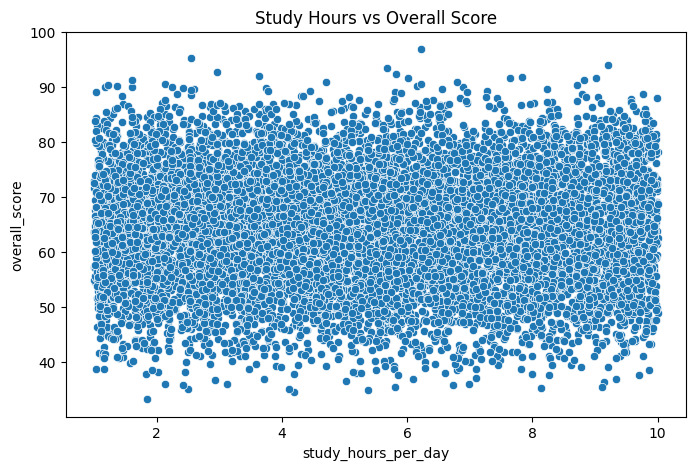

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='study_hours_per_day',
                y='overall_score')

plt.title('Study Hours vs Overall Score')
plt.show()

## 2. Does attendance percentage influence academic performance?

In [13]:
corr = df['attendance_percentage'].corr(df['overall_score'])
print("Correlation:", corr)

Correlation: 0.14878143875415112


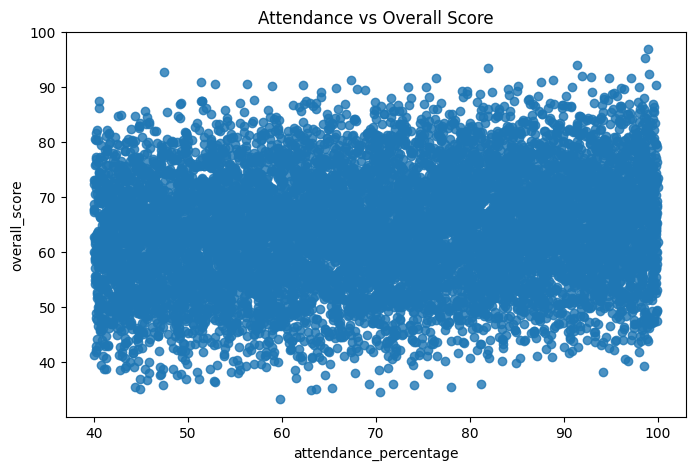

In [14]:
plt.figure(figsize=(8,5))
sns.regplot(data=df,
            x='attendance_percentage',
            y='overall_score')

plt.title('Attendance vs Overall Score')
plt.show()

## 3. Is there a performance difference between male and female students?

In [15]:
gender_score = df.groupby('gender')['overall_score'].mean()
print(gender_score)

gender
Female    63.830053
Male      63.823766
Name: overall_score, dtype: float64


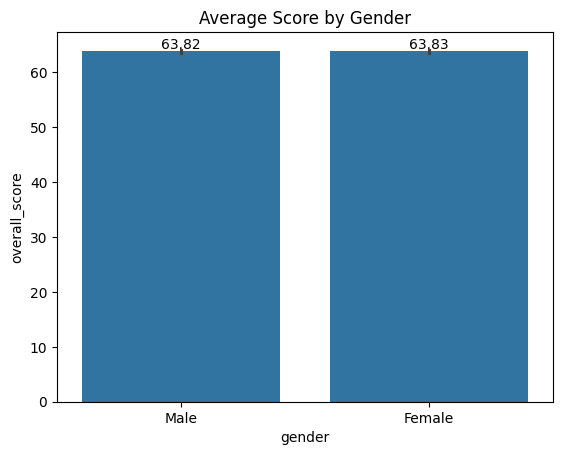

In [5]:
ax = sns.barplot(data=df,
            x='gender',
            y='overall_score')

plt.title('Average Score by Gender')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.show()

## 4. How does sleep duration affect academic performance?

In [17]:
corr = df['sleep_hours'].corr(df['overall_score'])
print("Correlation:", corr)

Correlation: -0.0005507843042598226


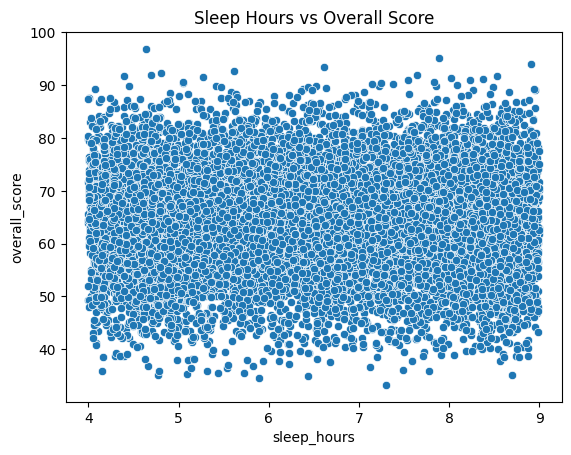

In [18]:
sns.scatterplot(data=df,
                x='sleep_hours',
                y='overall_score')

plt.title('Sleep Hours vs Overall Score')
plt.show()

## 5. Do students with internet access perform better academically?

In [19]:
internet_score = df.groupby('internet_access')['overall_score'].mean()
print(internet_score)

internet_access
No     63.525771
Yes    64.120773
Name: overall_score, dtype: float64


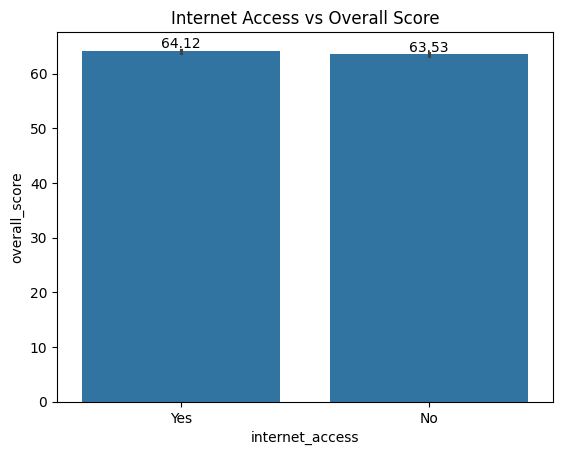

In [20]:
ax = sns.barplot(data=df,
            x='internet_access',
            y='overall_score')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.title('Internet Access vs Overall Score')
plt.show()

## 6. Does attending extra classes improve grades?

In [21]:
extra_score = df.groupby('extra_classes')['overall_score'].mean()
print(extra_score)

extra_classes
No     63.762164
Yes    63.889424
Name: overall_score, dtype: float64


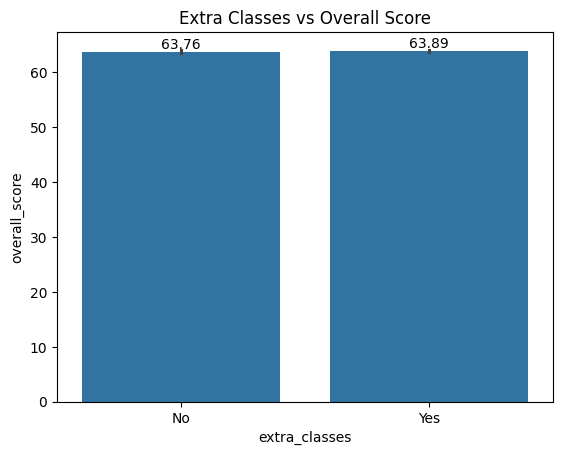

In [22]:
ax = sns.barplot(data=df,
                 x='extra_classes',
                 y='overall_score')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title('Extra Classes vs Overall Score')
plt.show()

## 7. How does parents' education influence student performance?

In [23]:
parent_score = df.groupby('parent_education')['overall_score'].mean()
print(parent_score)

parent_education
Bachelor       64.008239
High School    63.753196
Master         63.920976
PhD            63.621093
Name: overall_score, dtype: float64


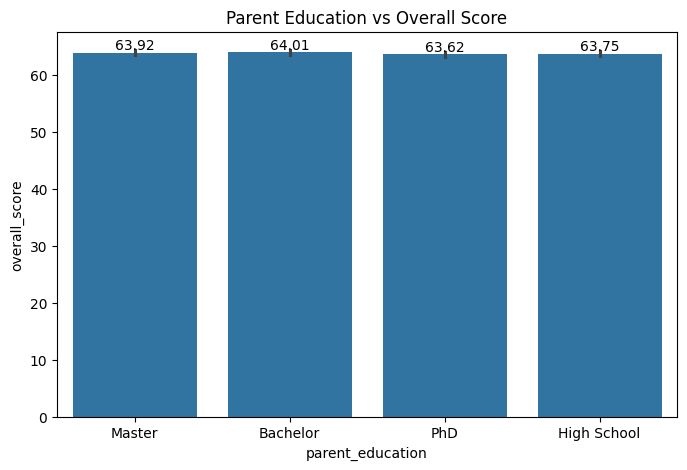

In [24]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=df,
            x='parent_education',
            y='overall_score')

for container in ax.containers: 
    ax.bar_label(container, fmt='%.2f')
    
plt.title("Parent Education vs Overall Score")
plt.show()

## 8. What is the relationship between participation score and overall performance?

In [25]:
corr = df['participation_score'].corr(df['overall_score'])
print("Correlation:", corr)

Correlation: 0.24406677309780572


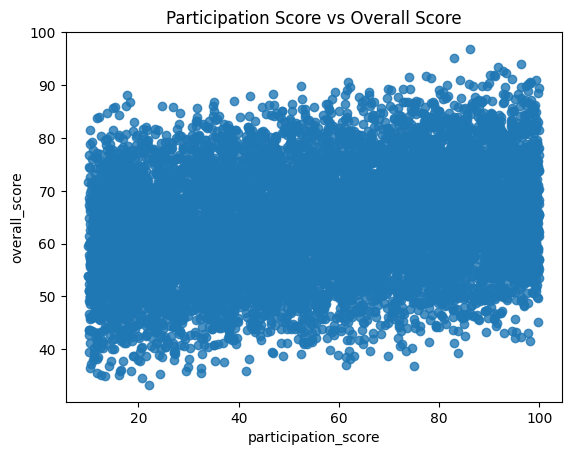

In [26]:
sns.regplot(data=df,
            x='participation_score',
            y='overall_score')

plt.title('Participation Score vs Overall Score')
plt.show()

## 9. Which grade category contains the highest number of students?

In [27]:
grade_count = df['grade'].value_counts()
print(grade_count)

grade
C    5073
B    2704
D    2008
A     154
F      61
Name: count, dtype: int64


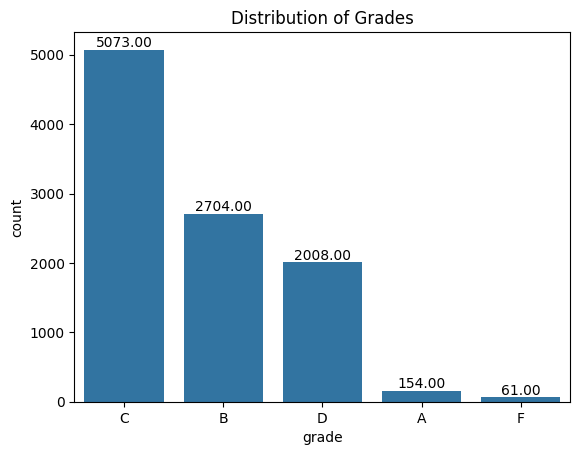

In [28]:
ax = sns.countplot(data=df,
              x='grade',
              order=grade_count.index)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.title('Distribution of Grades')
plt.show()

## 10. Does attendance percentage influence academic performance?

In [29]:
corr = df['attendance_percentage'].corr(df['overall_score'])
print("Correlation:", round(corr, 2))

Correlation: 0.15


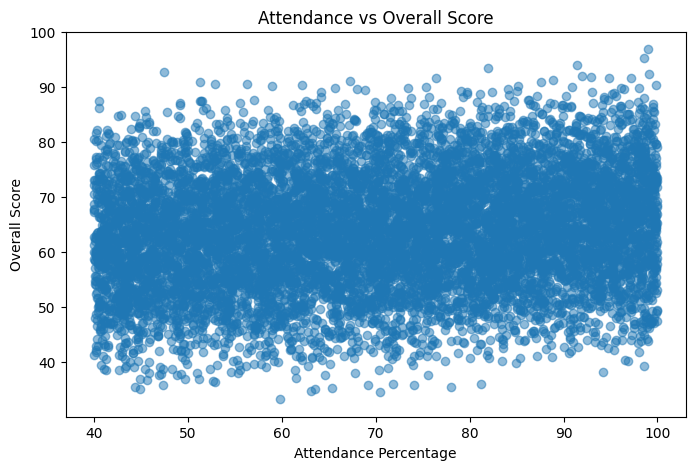

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(df['attendance_percentage'],
            df['overall_score'],
            alpha=0.5)

plt.xlabel("Attendance Percentage")
plt.ylabel("Overall Score")
plt.title("Attendance vs Overall Score")
plt.show()

## 11. Is there a performance difference between male and female students?

In [31]:
gender_score = df.groupby('gender')['overall_score'].mean()
print(gender_score)

gender
Female    63.830053
Male      63.823766
Name: overall_score, dtype: float64


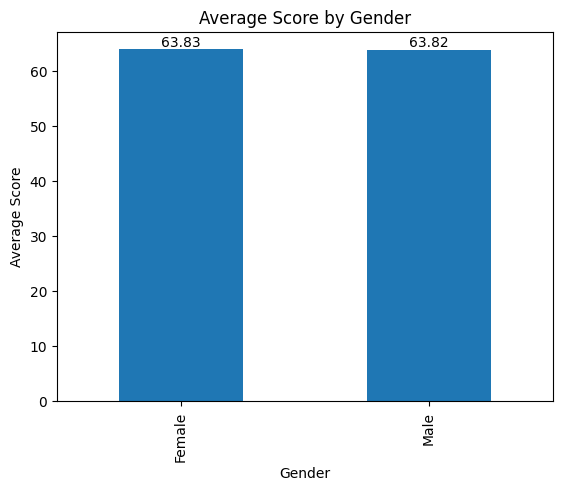

In [32]:
ax = gender_score.plot(kind='bar')
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.title("Average Score by Gender")

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

## 12. Which grade category contains the highest number of students?

In [33]:
grade_count = df['grade'].value_counts()
print(grade_count)

grade
C    5073
B    2704
D    2008
A     154
F      61
Name: count, dtype: int64


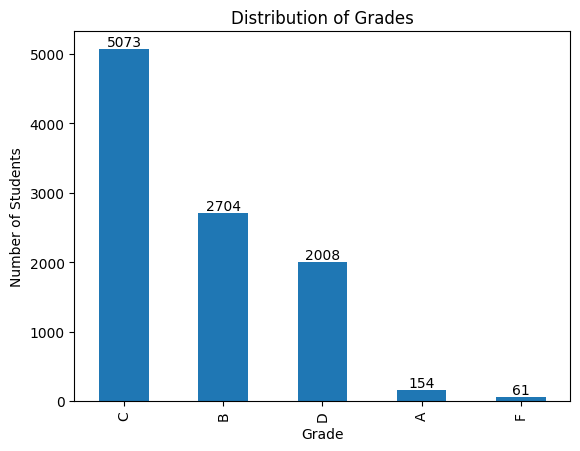

In [34]:
ax = grade_count.plot(kind='bar')

plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Grades")

for container in ax.containers: 
    ax.bar_label(container)
plt.show()

## 13. What factors have the strongest impact on overall scores?

In [35]:
corr = df.corr(numeric_only=True)['overall_score'].sort_values(ascending=False)
print(corr)

overall_score            1.000000
final_exam_score         0.689326
midterm_score            0.528902
assignment_score         0.396961
participation_score      0.244067
attendance_percentage    0.148781
student_id               0.007520
sleep_hours             -0.000551
study_hours_per_day     -0.003651
Name: overall_score, dtype: float64


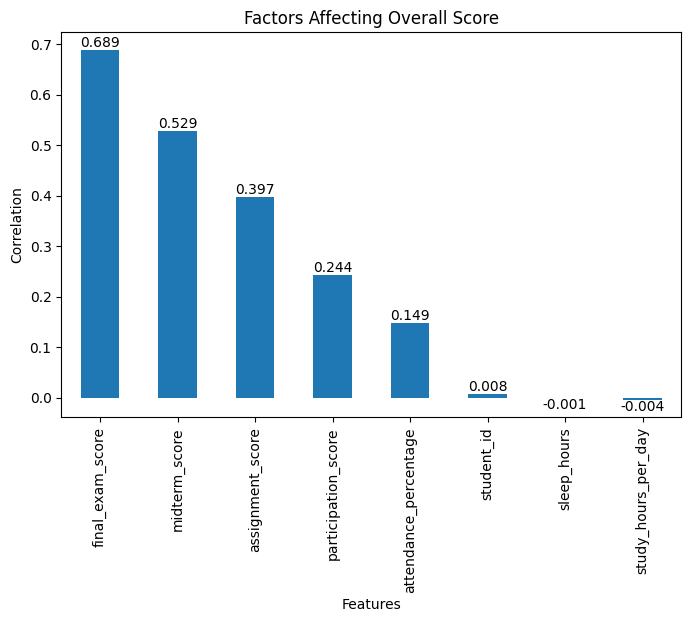

In [36]:
ax = corr.drop('overall_score').plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.xlabel("Features")
plt.ylabel("Correlation")
plt.title("Factors Affecting Overall Score")
plt.show()